# Task 2 spatial failure playground

Task 2 adds 3D coordinates, but the scorer does **not** care about absolute xyz coordinates. It cares about shape, scale, and which expression states are near each other.

This notebook uses the organizers' tiny public heart examples and deliberately changes one spatial property at a time. Because the known E9.5 target is used to construct these predictions, **this is a metric/intuition experiment, not a benchmark**.

We will test translation, rotation, reflection, uniform scaling, anisotropic stretching, and shuffling expression vectors among fixed coordinates. The last experiment is especially useful: the point cloud stays *exactly identical*, but the biological states attached to those points are scrambled.

In [1]:
!pip -q install "git+https://github.com/aristoteleo/veckit.git@46d41e63f42a9aab815db20b742feeccd249cb17" pandas matplotlib

In [2]:
from pathlib import Path
import urllib.request
DATA = Path('/content/vec_t2_failures')
DATA.mkdir(exist_ok=True)
base = 'https://raw.githubusercontent.com/aristoteleo/veckit/46d41e63f42a9aab815db20b742feeccd249cb17/data/'
for name in ['sample_heart_9.25.h5ad', 'sample_heart_9.5.h5ad']:
    p = DATA / name
    if not p.exists(): urllib.request.urlretrieve(base + name, p)
    print(name, round(p.stat().st_size / 1e6, 2), 'MB')

sample_heart_9.25.h5ad 0.56 MB


sample_heart_9.5.h5ad 0.57 MB


In [3]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from veckit import score

ref_path = DATA / 'sample_heart_9.25.h5ad'
target_path = DATA / 'sample_heart_9.5.h5ad'
target = ad.read_h5ad(target_path)
def dense_X(a):
    return a.X.toarray().astype(np.float32) if sparse.issparse(a.X) else np.asarray(a.X, dtype=np.float32)
X = dense_X(target)
C = np.asarray(target.obsm['spatial_3D'], dtype=np.float32)[:, :3]
center = C.mean(axis=0, keepdims=True)
Cc = C - center
print('target:', target.shape)

target: (150, 500)


## Build transformations with known meaning

The official spatial metrics are designed to ignore arbitrary coordinate frame. Moving or properly rotating the whole embryo should therefore be harmless. Scaling should matter because growth scale is part of the task. Anisotropic stretching changes shape.

The most informative control is **expression-location shuffle**: keep the exact same coordinates and the exact same collection of expression vectors, but attach each expression vector to a random position. Global shape is unchanged; local biological organization is not.

In [4]:
OUT = DATA / 'predictions'
OUT.mkdir(exist_ok=True)
rng = np.random.default_rng(0)
def save_pred(name, coords=None, X_new=None):
    pred = target.copy()
    if coords is not None: pred.obsm['spatial_3D'] = np.asarray(coords, dtype=np.float32)
    if X_new is not None: pred.X = np.asarray(X_new, dtype=np.float32)
    p = OUT / f'{name}.h5ad'
    pred.write_h5ad(p)
    return p

preds = {}
preds['translated'] = save_pred('translated', coords=C + np.array([100., -50., 25.]))
theta = np.deg2rad(67)
Rz = np.array([[np.cos(theta),-np.sin(theta),0.],[np.sin(theta),np.cos(theta),0.],[0.,0.,1.]], dtype=np.float32)
preds['rotated'] = save_pred('rotated', coords=Cc @ Rz.T + center)
C_reflect = Cc.copy(); C_reflect[:,0] *= -1
preds['reflected'] = save_pred('reflected', coords=C_reflect + center)
preds['scaled_x2'] = save_pred('scaled_x2', coords=2.0 * Cc + center)
A = np.diag([2.0, 0.5, 1.0]).astype(np.float32)
preds['anisotropic_stretch'] = save_pred('anisotropic_stretch', coords=Cc @ A.T + center)
perm = rng.permutation(target.n_obs)
preds['expression_location_shuffle'] = save_pred('expression_location_shuffle', coords=C, X_new=X[perm])
print('built:', list(preds))

built: ['translated', 'rotated', 'reflected', 'scaled_x2', 'anisotropic_stretch', 'expression_location_shuffle']


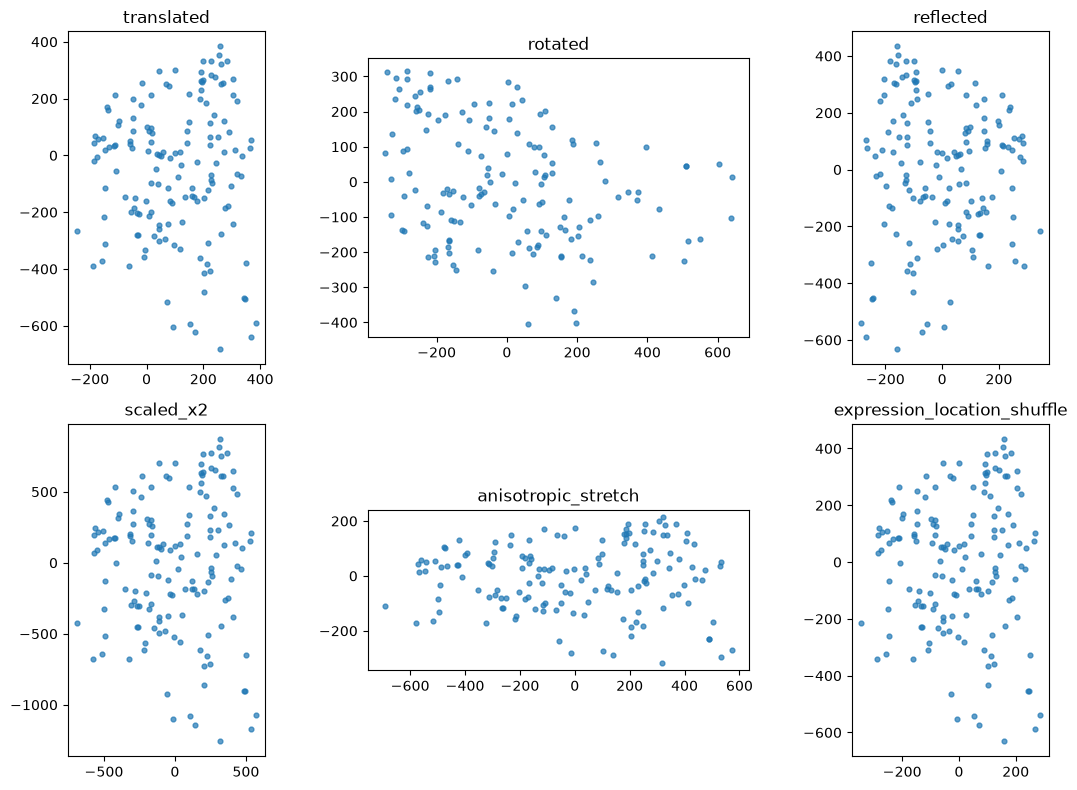

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (name, path) in zip(axes.flat, preds.items()):
    Adata = ad.read_h5ad(path)
    P = np.asarray(Adata.obsm['spatial_3D'])[:, :3]
    ax.scatter(P[:,0], P[:,1], s=12, alpha=0.7)
    ax.set_title(name); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Score the controlled failures

Useful spatial fields are `d2_shape`, `sliced_wasserstein`, `occupancy_dice`, `scale_log_ratio`, `neighborhood_mmd`, and `morans_I_agreement`. We also keep `mmd_u` and `variogram` as expression controls. For coordinate-only transformations, expression is unchanged, so expression-only metrics should stay fixed.

In [6]:
metric_names = ['mmd_u','variogram','d2_shape','sliced_wasserstein','occupancy_dice','scale_log_ratio','neighborhood_mmd','morans_I_agreement']
rows = []
for name, path in preds.items():
    result = score(task='T2', setting='heart', input=path, target=target_path, reference=ref_path)
    m = result['metrics']
    rows.append({'prediction': name, **{k: m.get(k) for k in metric_names}})
scores = pd.DataFrame(rows).set_index('prediction')
display(scores.round(5))

/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,mmd_u,variogram,d2_shape,sliced_wasserstein,occupancy_dice,scale_log_ratio,neighborhood_mmd,morans_I_agreement
prediction,,,,,,,,
translated,-0.00807,0.0,0.00126,0.00000,1.0000,-0.0000,-0.00793,1.0000
rotated,-0.00807,0.0,0.00126,0.03846,0.6275,0.0000,-0.00793,1.0000
reflected,-0.00807,0.0,0.00126,0.00000,1.0000,-0.0000,-0.00793,1.0000
scaled_x2,-0.00807,0.0,0.00126,0.00000,1.0000,0.6931,-0.00793,1.0000
anisotropic_stretch,-0.00807,0.0,0.05617,0.07799,0.5895,0.1136,0.00818,0.9252
expression_location_shuffle,-0.00807,0.0,0.00126,0.00000,1.0000,0.0000,0.12104,0.0741


## The key comparison: same shape, wrong biology

`expression_location_shuffle` keeps exactly the same coordinate point cloud, exactly the same collection of expression vectors, and exactly the same cell count. Only the mapping between expression state and position changes.

So global shape metrics and expression-distribution metrics should barely move, while local spatial-organization metrics should react. That is the difference between ‘did I draw the right embryo-shaped cloud?’ and ‘did the right biological states end up next to each other?’

,mmd_u,variogram,d2_shape,sliced_wasserstein,occupancy_dice,scale_log_ratio,neighborhood_mmd,morans_I_agreement
prediction,,,,,,,,
translated,-0.00807,0.0,0.00126,0.00000,1.0000,-0.0000,-0.00793,1.0000
rotated,-0.00807,0.0,0.00126,0.03846,0.6275,0.0000,-0.00793,1.0000
scaled_x2,-0.00807,0.0,0.00126,0.00000,1.0000,0.6931,-0.00793,1.0000
anisotropic_stretch,-0.00807,0.0,0.05617,0.07799,0.5895,0.1136,0.00818,0.9252
expression_location_shuffle,-0.00807,0.0,0.00126,0.00000,1.0000,0.0000,0.12104,0.0741


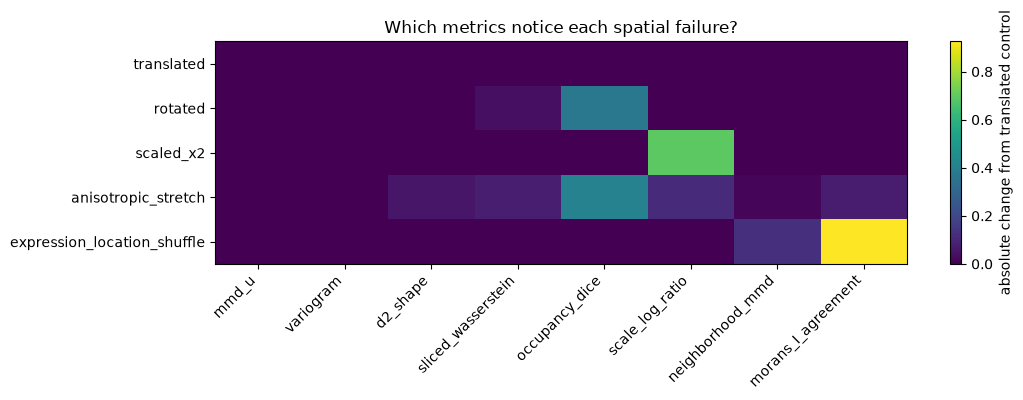

In [7]:
focus = scores.loc[['translated','rotated','scaled_x2','anisotropic_stretch','expression_location_shuffle']]
display(focus.round(5))
delta = (focus - focus.loc['translated']).abs()
plt.figure(figsize=(11,4)); plt.imshow(delta.to_numpy(), aspect='auto')
plt.xticks(range(len(delta.columns)), delta.columns, rotation=45, ha='right')
plt.yticks(range(len(delta.index)), delta.index)
plt.colorbar(label='absolute change from translated control')
plt.title('Which metrics notice each spatial failure?'); plt.tight_layout(); plt.show()

## What should you learn?

- **Translation and proper rotation are coordinate-frame choices, not biological errors.** The official scorer is designed to ignore them.
- **Scale and shape are different questions.** A uniformly enlarged embryo and an anisotropically stretched one fail differently.
- **Global geometry is not local organization.** You can keep the exact point cloud and still put the wrong cell states next to each other.
- **Coordinate MSE is a poor objective by itself.** It can punish harmless frame changes while failing to express the relational structure the challenge scores.

The bundled samples are tiny, so use the experiment qualitatively and repeat important diagnostics on the full released training stages.

Sources: https://virtualembryo.ai/challenge/evaluation?section=submissions&task=2, https://virtualembryo.ai/challenge/evaluation?section=scoring&task=2, and https://github.com/aristoteleo/veckit